# Deep Learning-Based Assessment Model for Visual Learner Identification using Raw EEG

> **Paper:** Jawed, Faye & Malik — *IEEE Transactions on Neural Systems and Rehabilitation Engineering*, Vol. 32, 2024  
> **Goal:** Classify EEG signals (eyes-closed resting state) as **Visual Learner (L)** or **Non-Visual Learner (NL)**  
> **Best model:** LSTM-CNN → Accuracy **94%**, Sensitivity **80%**, Specificity **92%**, F1 **94%**

## Model Introduction

This project focuses on **EEG-based classification using deep learning**. The model is designed to learn meaningful patterns from EEG signals and classify them into the target classes.

The proposed architecture combines **CNN and LSTM layers** to capture both spatial/local features and temporal patterns present in EEG recordings. To improve generalization and reduce overfitting, the model uses **Global Average Pooling, dropout, L2 regularization, class weighting, and learning-rate scheduling**.

The model is evaluated using a **subject-level data split**, ensuring that EEG segments from the same subject do not appear in both training and testing sets. This provides a more reliable estimate of the model's performance on unseen subjects.

> **Important:** The model should be trained and evaluated using real EEG recordings. Synthetic/random data is used only as a placeholder when the actual dataset is unavailable, and results obtained from such data should not be considered meaningful.


## 1. Install & Imports

In [5]:
# NUMPY & VISUALIZATION LIBRARIES

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

In [6]:
# TENSORFLOW / KERAS

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers

In [7]:
# SCIKIT-LEARN

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_auc_score,
    roc_curve, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

In [8]:
# CHECK LIBRARY SETUP

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
NumPy version: 2.3.5
All libraries imported successfully!


In [9]:
# MNE (for reading EEGMMIDB .edf files) + requests (for downloading from PhysioNet)

!pip install mne edfio --quiet

import mne
import requests

print("mne version:", mne.__version__)


mne version: 1.13.2


## 2. Configuration — Hyperparameters-

## EEG signal settings-

In [10]:
N_CHANNELS = 64 # EEGMMIDB has 64 EEG channels
SAMPLE_RATE = 160 # EEGMMIDB native sampling rate (Hz)
SEGMENT_SEC = 10 # Window length per segment, in seconds
N_SAMPLES = SEGMENT_SEC * SAMPLE_RATE

N_CLASSES = 2

print("EEG Channels:", N_CHANNELS)
print("Sampling Rate:", SAMPLE_RATE, "Hz")
print("Segment Length:", SEGMENT_SEC, "seconds")
print("Samples per Segment:", N_SAMPLES)
print("Number of Classes:", N_CLASSES)


EEG Channels: 64
Sampling Rate: 160 Hz
Segment Length: 10 seconds
Samples per Segment: 1600
Number of Classes: 2


In [11]:
#  Data source -

EEGMMIDB_BASE_URL = "https://physionet.org/files/eegmmidb/1.0.0"
EEGMMIDB_DATA_DIR = "./eegmmidb_data"

# 40 subjects-
EEGMMIDB_SUBJECTS = list(range(1, 41))

# 50% overlap for training-
OVERLAP_TRAIN = 0.5

# No overlap for test and validetion-
OVERLAP_TEST = 0.0

# R01 = eyes-open (label 0), R02 = eyes-closed (label 1)
BASELINE_RUNS = {1: 0, 2: 1}

# Subjects recorded at non-standard sample rates
IRREGULAR_SUBJECTS = {88, 89, 92, 100, 104, 106}

## Model Hyperparameters -

In [12]:
# Model hyperparameters-
CNN_FILTERS_1 = 32
CNN_FILTERS_2 = 64
KERNEL_SIZE = 5
POOL_SIZE = 2
LSTM_UNITS = 64

# Regularization settings-
DROPOUT_RATE = 0.3
L2_REG = 1e-4

## Training Parameters

In [13]:
BATCH_SIZE = 32
EPOCHS = 100

# Learning rate-
LEARNING_RATE = 1e-3

# Early stopping-
PATIENCE_ES = 20

# ReduceLROnPlateau patience-
PATIENCE_LR = 8

LR_FACTOR = 0.5


## Experiment settings

In [14]:
# Experiment-
RANDOM_SEED = 42

# Cross-validation folds-
N_FOLDS = 3
RUN_CV = True

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Segment shape : ({N_SAMPLES}, {N_CHANNELS})")
print(f"Subjects : {len(EEGMMIDB_SUBJECTS)}")
print(f"Classes : {N_CLASSES}")
print(f"Seed : {RANDOM_SEED}")

TensorFlow version : 2.21.0
Segment shape : (1600, 64)
Subjects : 40
Classes : 2
Seed : 42


## 3. Dataset Loading

> **Paper protocol:**  
> - 34 subjects, eyes-closed resting-state EEG  
> - Segmented into 1-minute non-overlapping chunks → shape `(15000, 102)`  
> - Labels: median RAPM score split → ≥ median = Visual Learner (1), < median = Non-Visual (0)  
> - 75% train / 25% test, no overlap between splits

## Load Data from Archive-

In [15]:
# DOWNLOAD HELPERS-

def _eegmmidb_url(subject, run):
    return (
        f"{EEGMMIDB_BASE_URL}/"
        f"S{subject:03d}/S{subject:03d}R{run:02d}.edf"
    )


def _download_edf(subject, run, data_dir=EEGMMIDB_DATA_DIR):
    os.makedirs(data_dir, exist_ok=True)
    fname = f"S{subject:03d}R{run:02d}.edf"
    path = os.path.join(data_dir, fname)

    if os.path.exists(path):
        return path

    url = _eegmmidb_url(subject, run)
    print(f"  Downloading {fname}...")

    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    with open(path, 'wb') as f:
        f.write(resp.content)

    return path


In [16]:
# PREPROCESS & SEGMENT

def _preprocess_and_segment(
    raw,
    segment_sec = SEGMENT_SEC,
    n_channels = N_CHANNELS,
    sample_rate = SAMPLE_RATE,
    overlap=0.5
):
    raw = raw.copy()

    # Bandpass filter 1–45 Hz-
    raw.filter(
        l_freq=1.0,
        h_freq=45.0,
        method='iir',
        iir_params=dict(order=4, ftype='butter'),
        verbose=False
    )

    # Notch filter at 60 Hz-
    raw.notch_filter(
        freqs=60.0,
        method='iir',
        verbose=False
    )

    # Resample if needed -
    if (abs(raw.info['sfreq'] - sample_rate) > 0.01):

        raw.resample(sample_rate, verbose=False)

    # Extract data: (channels, time) to (time, channels) -
    data = raw.get_data()

    if data.shape[0] < n_channels:
        raise ValueError(
            f"Expected {n_channels} channels, got {data.shape[0]}"
        )

    data = data[:n_channels].T



# Clip extreme values (artifact rejection)-

    # EEG values in volts; 500 µV = 500e-6 V
    clip_threshold = 500e-6
    data = np.clip(data, -clip_threshold, clip_threshold)

    # Segment with overlap-
    n_samples = int(segment_sec * sample_rate)
    step = max(1, int(n_samples * (1 - overlap)))

    segments = []
    start = 0
    while start + n_samples <= data.shape[0]:
        segments.append(data[start:start + n_samples])
        start += step

    return segments

In [17]:
# LOAD ONE FILE-

def _load_one_baseline_file(
    subject, run, label,
    data_dir = EEGMMIDB_DATA_DIR,
    overlap = 0.5
):
    path = _download_edf(subject, run, data_dir)

    raw = mne.io.read_raw_edf(
        path, preload = True, verbose = False
    )

    segments = _preprocess_and_segment(
        raw,
        SEGMENT_SEC,
        N_CHANNELS,
        SAMPLE_RATE,
        overlap
    )

    if not segments:
        return (
            np.zeros((0, N_SAMPLES, N_CHANNELS), dtype=np.float32),
            np.zeros(0, dtype=np.int32),
            np.zeros(0, dtype=np.int32)
        )

    X = np.stack(segments).astype(np.float32)
    y = np.full(len(segments), label, dtype=np.int32)
    sids = np.full(len(segments), subject, dtype=np.int32)

    return X, y, sids


In [18]:
# EEGMMIDB BASELINE LOADER -

def load_eegmmidb_baseline(subjects, overlap=0.5):

    X_all = []
    y_all = []
    subject_ids_all = []

    # Loop through subjects -
    for subject in subjects:
        print(f"\nSubject {subject}")

        # R01 = eyes-open (label 0), R02 = eyes-closed (label 1)-
        for run, label in BASELINE_RUNS.items():

            try:
                X, y, sids = _load_one_baseline_file(
                    subject, run, label,
                    data_dir=EEGMMIDB_DATA_DIR,
                    overlap=overlap
                )
            except Exception as e:
                print(f"  ERROR subject {subject} run R{run:02d}: {e}")
                continue

            if len(X) == 0:
                print(f"  WARNING: no segments for subject {subject} run R{run:02d}")
                continue

            X_all.append(X)
            y_all.append(y)
            subject_ids_all.append(sids)

            print(f"  R{run:02d}: {len(X)} segments, shape {X.shape[1:]}")

    if not X_all:
        return (
            np.zeros((0, N_SAMPLES, N_CHANNELS), dtype=np.float32),
            np.zeros(0, dtype=np.int64),
            np.zeros(0, dtype=np.int64)
        )

    X_all = np.concatenate(X_all, axis=0).astype(np.float32)
    y_all = np.concatenate(y_all, axis=0).astype(np.int64)
    subject_ids_all = np.concatenate(subject_ids_all, axis=0).astype(np.int64)

    print("\nFinished loading all subjects.")
    print("X shape:", X_all.shape)
    print("y shape:", y_all.shape)
    print("Subject IDs:", len(np.unique(subject_ids_all)))

    return X_all, y_all, subject_ids_all


## Load & Preprocess Data-

In [19]:
# NOTE: the real load_eegmmidb_baseline() is defined above (Cell 23)
# and uses _load_one_baseline_file() / _preprocess_and_segment() for
# proper filtering, resampling and segmenting. (This cell used to
# redefine the function as an empty stub which silently produced
# empty X_all/y_all/subject_ids_all arrays -- that redefinition has
# been removed.)


In [20]:
# Load all subjects with preprocessing

print("Loading EEGMMIDB baseline recordings.")
print("(Subjects 21 to 40 will be downloaded on first run)\n")

X_all, y_all, subject_ids_all = load_eegmmidb_baseline(
    EEGMMIDB_SUBJECTS,
    overlap=OVERLAP_TRAIN
)

print(f"\nTotal segments: {len(X_all)}")
print(f"Segment shape: {X_all.shape[1:]}")
print(f"Unique subjects: {len(np.unique(subject_ids_all))}")

Loading EEGMMIDB baseline recordings.
(Subjects 21 to 40 will be downloaded on first run)


Subject 1


  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 2
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 3
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 4
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 5
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 6
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 7
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 8
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 9
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 10
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 11
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape (1600, 64)

Subject 12
  R01: 11 segments, shape (1600, 64)
  R02: 11 segments, shape

## Subject-wise Train / Validation / Test Split

Three-way subject split:
- **60%** train subjects — model training
- **15%** validation subjects — model selection, early stopping
- **25%** test subjects — single final evaluation (untouched)

No subject appears in more than one set.

In [21]:
# STEP 1: Separate TEST subjects (25%)

print("Starting subject-wise train/validation/test split...")

# Basic validation
assert len(X_all) > 0, "X_all is empty!"
assert len(y_all) > 0, "y_all is empty!"
assert len(subject_ids_all) > 0, "subject_ids_all is empty!"

assert len(X_all) == len(y_all), \
    "X_all and y_all have different numbers of samples!"

assert len(X_all) == len(subject_ids_all), \
    "X_all and subject_ids_all have different numbers of samples!"

print(f"Total samples: {len(X_all)}")
print(f"Total subjects: {len(np.unique(subject_ids_all))}")


# ------------------------------------------------------------
# TEST = 25% of subjects
# ------------------------------------------------------------

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_SEED
)

trainval_idx, test_idx = next(
    gss_test.split(
        X_all,
        y_all,
        groups=subject_ids_all
    )
)

X_trainval = X_all[trainval_idx]
y_trainval = y_all[trainval_idx]
subjects_trainval = subject_ids_all[trainval_idx]

X_test = X_all[test_idx]
y_test = y_all[test_idx]
subjects_test = subject_ids_all[test_idx]


# ============================================================
# STEP 2: Separate VALIDATION from TRAIN
# 20% of remaining subjects
# ============================================================

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_idx_rel, val_idx_rel = next(
    gss_val.split(
        X_trainval,
        y_trainval,
        groups=subjects_trainval
    )
)

X_train = X_trainval[train_idx_rel]
y_train = y_trainval[train_idx_rel]
subjects_train = subjects_trainval[train_idx_rel]

X_val = X_trainval[val_idx_rel]
y_val = y_trainval[val_idx_rel]
subjects_val = subjects_trainval[val_idx_rel]


# ============================================================
# STEP 3: VERIFY NO SUBJECT LEAKAGE
# ============================================================

train_subj = set(np.unique(subjects_train))
val_subj = set(np.unique(subjects_val))
test_subj = set(np.unique(subjects_test))

assert train_subj.isdisjoint(val_subj), \
    "LEAK: Train and Validation subjects overlap!"

assert train_subj.isdisjoint(test_subj), \
    "LEAK: Train and Test subjects overlap!"

assert val_subj.isdisjoint(test_subj), \
    "LEAK: Validation and Test subjects overlap!"


# ============================================================
# STEP 4: PRINT RESULTS
# ============================================================

print("\n" + "=" * 65)
print("SUBJECT-WISE SPLIT - NO LEAKAGE VERIFIED")
print("=" * 65)

print(
    f"Train : {len(X_train):5d} segments, "
    f"{len(train_subj):2d} subjects {sorted(train_subj)}"
)

print(
    f"Val   : {len(X_val):5d} segments, "
    f"{len(val_subj):2d} subjects {sorted(val_subj)}"
)

print(
    f"Test  : {len(X_test):5d} segments, "
    f"{len(test_subj):2d} subjects {sorted(test_subj)}"
)

print("\nTrain label distribution:")
print(dict(zip(*np.unique(y_train, return_counts=True))))

print("\nValidation label distribution:")
print(dict(zip(*np.unique(y_val, return_counts=True))))

print("\nTest label distribution:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Starting subject-wise train/validation/test split...
Total samples: 880
Total subjects: 40

SUBJECT-WISE SPLIT - NO LEAKAGE VERIFIED
Train :   528 segments, 24 subjects [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(14), np.int64(15), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(26), np.int64(29), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(35), np.int64(37), np.int64(39)]
Val   :   132 segments,  6 subjects [np.int64(11), np.int64(12), np.int64(22), np.int64(24), np.int64(32), np.int64(36)]
Test  :   220 segments, 10 subjects [np.int64(5), np.int64(7), np.int64(13), np.int64(16), np.int64(17), np.int64(20), np.int64(27), np.int64(28), np.int64(38), np.int64(40)]

Train label distribution:
{np.int64(0): np.int64(264), np.int64(1): np.int64(264)}

Validation label distribution:
{np.int64(0): np.int64(66), np.int64(1): np.int64(66)}

Test label distribution:
{np.int6

## Training-only Normalization

Per-channel z-score using **training data statistics only**.
Applied identically to train, validation, and test sets.

In [22]:
# Z-SCORE NORMALIZATION (training stats only)-

mu = X_train.mean(axis = (0, 1), keepdims = True)
sigma = X_train.std(axis = (0, 1), keepdims = True) + 1e-8

X_train = (X_train - mu) / sigma
X_val = (X_val - mu) / sigma
X_test = (X_test - mu) / sigma

# Convert labels to categorical-
y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val, N_CLASSES)
y_test_cat  = to_categorical(y_test, N_CLASSES)

# Class weights -
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes.astype(int), weights))

print("Normalization applied (training stats only).")
print(f"Train mean ~ {X_train.mean() : .4f}, std ~ {X_train.std(): .4f}")
print(f"Val  mean ~ {X_val.mean():.4f}, std ~ {X_val.std() : .4f}")
print(f"Test mean ~ {X_test.mean():.4f}, std ~ {X_test.std() : .4f}")
print(f"Class weights: {class_weight_dict}")

Normalization applied (training stats only).
Train mean ~  0.0000, std ~  0.9997
Val  mean ~ -0.0005, std ~  1.0184
Test mean ~ 0.0002, std ~  0.9742
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


## Baseline Model (LSTM-CNN)

Reproduces the current notebook's LSTM-CNN architecture for fair comparison.
Fixed: accepts `input_shape` and `n_classes` as parameters (no global references).

In [23]:
def build_baseline_lstm_cnn(input_shape, n_classes):

    inp = keras.Input(shape=input_shape)

    # LSTM (processes full 640-step sequence)-
    x = layers.LSTM(64, return_sequences = True)(inp)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # CNN block 1-
    x = layers.Conv1D(32, kernel_size = 3, padding='same', activation = 'relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size = 2)(x)

    # CNN block 2-
    x = layers.Conv1D(64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier
    x = layers.Dense(64, activation = 'relu')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    out = layers.Dense(n_classes, activation = 'softmax')(x)


    model = keras.Model(inp, out, name = 'Baseline_LSTM_CNN')
    model.compile(
        optimizer=Adam (learning_rate = LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [24]:
# Quick test-

_test = build_baseline_lstm_cnn((N_SAMPLES, N_CHANNELS), N_CLASSES)
print(f"Baseline LSTM-CNN : {_test.count_params():,} parameters")

del _test

Baseline LSTM-CNN : 50,082 parameters


## Improved Models

**Key improvements over baseline:**
1. **CNN before LSTM** — extract local features first, reduce sequence length (640 → 160),
   making LSTM faster and more effective
2. **Bidirectional LSTM** — captures both forward and backward temporal patterns
3. **Temporal Attention** — learns which time regions are most discriminative
4. **L2 regularization + Dropout** — prevents overfitting with limited data
5. **BatchNormalization** throughout — stabilizes training

In [25]:
# ============================================================
# TEMPORAL ATTENTION LAYER
# ============================================================

class TemporalAttention(layers.Layer):
    """
    Input:  (batch, timesteps, features)
    Output: (batch, features)
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        d = int(input_shape[-1])

        self.W = self.add_weight(
            name='att_W',
            shape=(d, d),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            name='att_b',
            shape=(d,),
            initializer='zeros',
            trainable=True
        )

        self.u = self.add_weight(
            name='att_u',
            shape=(d,),
            initializer='glorot_uniform',
            trainable=True
        )

        super().build(input_shape)

    def call(self, x):

        score = tf.nn.tanh(
            tf.matmul(x, self.W) + self.b
        )

        alpha = tf.nn.softmax(
            tf.reduce_sum(
                score * self.u,
                axis=-1,
                keepdims=True
            ),
            axis=1
        )

        return tf.reduce_sum(
            x * alpha,
            axis=1
        )

    def get_config(self):
        return super().get_config()

## CNN-LSTM MODEL

In [ ]:


def build_cnn_lstm(input_shape, n_classes):

    inp = keras.Input(shape=input_shape)

    # CNN Block 1
    # (640, 64) -> (320, 32)
    x = layers.Conv1D(
        CNN_FILTERS_1,
        KERNEL_SIZE,
        padding='same',
        kernel_regularizer=regularizers.l2(L2_REG)
    )(inp)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # CNN Block 2
    # (320, 32) -> (160, 64)
    x = layers.Conv1D(
        CNN_FILTERS_2,
        3,
        padding='same',
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # LSTM
    # Reduced sequence: 160 steps instead of 640
    x = layers.LSTM(
        LSTM_UNITS,
        dropout=0.2
    )(x)

    # Classifier
    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.Dropout(DROPOUT_RATE)(x)

    # Output
    out = layers.Dense(
        n_classes,
        activation='softmax'
    )(x)

    # Create model
    model = keras.Model(
        inp,
        out,
        name='CNN_LSTM'
    )

    # Compile
    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# 
model = build_cnn_lstm(
    input_shape=(N_SAMPLES, N_CHANNELS),
    n_classes=N_CLASSES
)

In [35]:
model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1600, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1600, 32)       │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1600, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1600, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 800, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 800, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 800, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,178 (211.63 KB)

 Trainable params: 53,986 (210.88 KB)

 Non-trainable params: 192 (768.00 B)

## CNN-BiLSTM -

In [52]:
# CNN-BiLSTM

def build_cnn_bilstm(input_shape, n_classes):
    inp = keras.Input(shape=input_shape)

    # CNN block 1-
    x = layers.Conv1D(CNN_FILTERS_1, KERNEL_SIZE, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(inp)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # CNN block 2-
    x = layers.Conv1D(CNN_FILTERS_2, 3, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # Bidirectional LSTM-
    x = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, dropout=0.2)
    )(x)

    # Classifier-
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out, name='CNN_BiLSTM')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [53]:
model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1600, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1600, 32)       │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1600, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1600, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 800, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 800, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 800, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,178 (211.63 KB)

 Trainable params: 53,986 (210.88 KB)

 Non-trainable params: 192 (768.00 B)

## CNN-BiLSTM-ATTENTION -

In [55]:
# CNN-BiLSTM-ATTENTION

def build_cnn_bilstm_attention(input_shape, n_classes):
    """CNN + BiLSTM + Temporal Attention for selective focus."""
    inp = keras.Input(shape=input_shape)

    # CNN block 1-
    x = layers.Conv1D(CNN_FILTERS_1, KERNEL_SIZE, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(inp)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # CNN block 2 -
    x = layers.Conv1D(CNN_FILTERS_2, 3, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(POOL_SIZE)(x)
    x = layers.Dropout(0.2)(x)

    # Bidirectional LSTM -
    x = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2)
    )(x)

    # Temporal Attention-
    x = TemporalAttention()(x)

    # Classifier -
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out, name='CNN_BiLSTM_Attention')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [56]:
model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1600, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1600, 32)       │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1600, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1600, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 800, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 800, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 800, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 800, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,178 (211.63 KB)

 Trainable params: 53,986 (210.88 KB)

 Non-trainable params: 192 (768.00 B)

In [57]:
model_builders = {
    'Baseline LSTM-CNN': build_baseline_lstm_cnn,
    'CNN-LSTM': build_cnn_lstm,
    'CNN-BiLSTM': build_cnn_bilstm,
    'CNN-BiLSTM-Attention': build_cnn_bilstm_attention,
}

print("Model architectures defined:")

for name, fn in model_builders.items():
    m = fn(
        (N_SAMPLES, N_CHANNELS),
        N_CLASSES
    )
    
    print(f"{name:<25s}: {m.count_params():>8,} params")
    del m

tf.keras.backend.clear_session()

Model architectures defined:
Baseline LSTM-CNN        :   50,082 params
CNN-LSTM                 :   54,178 params
CNN-BiLSTM               :   91,298 params

CNN-BiLSTM-Attention     :  107,938 params


## Training Callbacks

In [58]:
def get_callbacks(model_name="model"):
    return [
        EarlyStopping(
            monitor ='val_loss',
            patience = PATIENCE_ES,
            restore_best_weights = True,
            verbose = 1
        ),

        ReduceLROnPlateau(
            monitor = 'val_loss',
            factor = LR_FACTOR,
            patience = PATIENCE_LR,
            min_lr = 1e-6,
            verbose = 1
        ),
    ]


def plot_training_history(histories):
    
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, (name, hist) in enumerate (histories.items()):

        # Accuracy-
        axes[i, 0].plot (hist.history ['accuracy'], label = 'Train', linewidth = 2)
        axes[i, 0].plot (hist.history ['val_accuracy'], label = 'Val' , linewidth = 2)
        axes[i, 0].set_title (f' {name} \u2014 Accuracy')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel('Accuracy')
        axes[i, 0].legend()
        axes[i, 0].grid(alpha = 0.3)

        # Loss-
        axes[i, 1].plot (hist.history ['loss'], label = 'Train', linewidth = 2)
        axes[i, 1].plot (hist.history ['val_loss'], label = 'Val', linewidth = 2)
        axes[i, 1].set_title(f'{name} \u2014 Loss')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel('Loss')
        axes[i, 1].legend()
        axes[i, 1].grid(alpha = 0.3)

    plt.tight_layout()
    plt.show()

print("Training utilities ready.")

Training utilities ready.


## Train All Models-

In [59]:
# TRAIN ALL MODELS

trained_models = {}
histories = {}

for name, build_fn in model_builders.items():
    print(f"\n {' = ' * 60}")
    print(f"Training : {name}")
    print(f"{'=' * 60}")

    # Clear session for clean start-
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # Build model -
    model = build_fn(
        input_shape=(N_SAMPLES, N_CHANNELS),
        n_classes=N_CLASSES
    )

    # Train with validation set -
    history = model.fit(
        X_train, y_train_cat,
        validation_data = (X_val, y_val_cat),
        batch_size = BATCH_SIZE,
        epochs = EPOCHS,
        callbacks = get_callbacks(name),
        class_weight = class_weight_dict,
        verbose = 1
    )

    trained_models[name] = model
    histories[name] = history

    # Quick check
    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    print(f"Final val accuracy: {val_acc:.4f}")

print("\n All models trained.")


  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Training : Baseline LSTM-CNN
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 711ms/step - accuracy: 0.7159 - loss: 0.5508 - val_accuracy: 0.8939 - val_loss: 0.6113 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 593ms/step - accuracy: 0.8523 - loss: 0.3721 - val_accuracy: 0.8030 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 595ms/step - accuracy: 0.8920 - loss: 0.2711 - val_accuracy: 0.7424 - val_loss: 0.4894 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 655ms/step - accuracy: 0.9337 - loss: 0.1875 - val_accuracy: 0.7273 - val_loss: 0.4731 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 557ms/step - accuracy: 0.9470 - loss: 0.1341 - val_accuracy: 0.8939 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 6/100
17/17 

### Training History

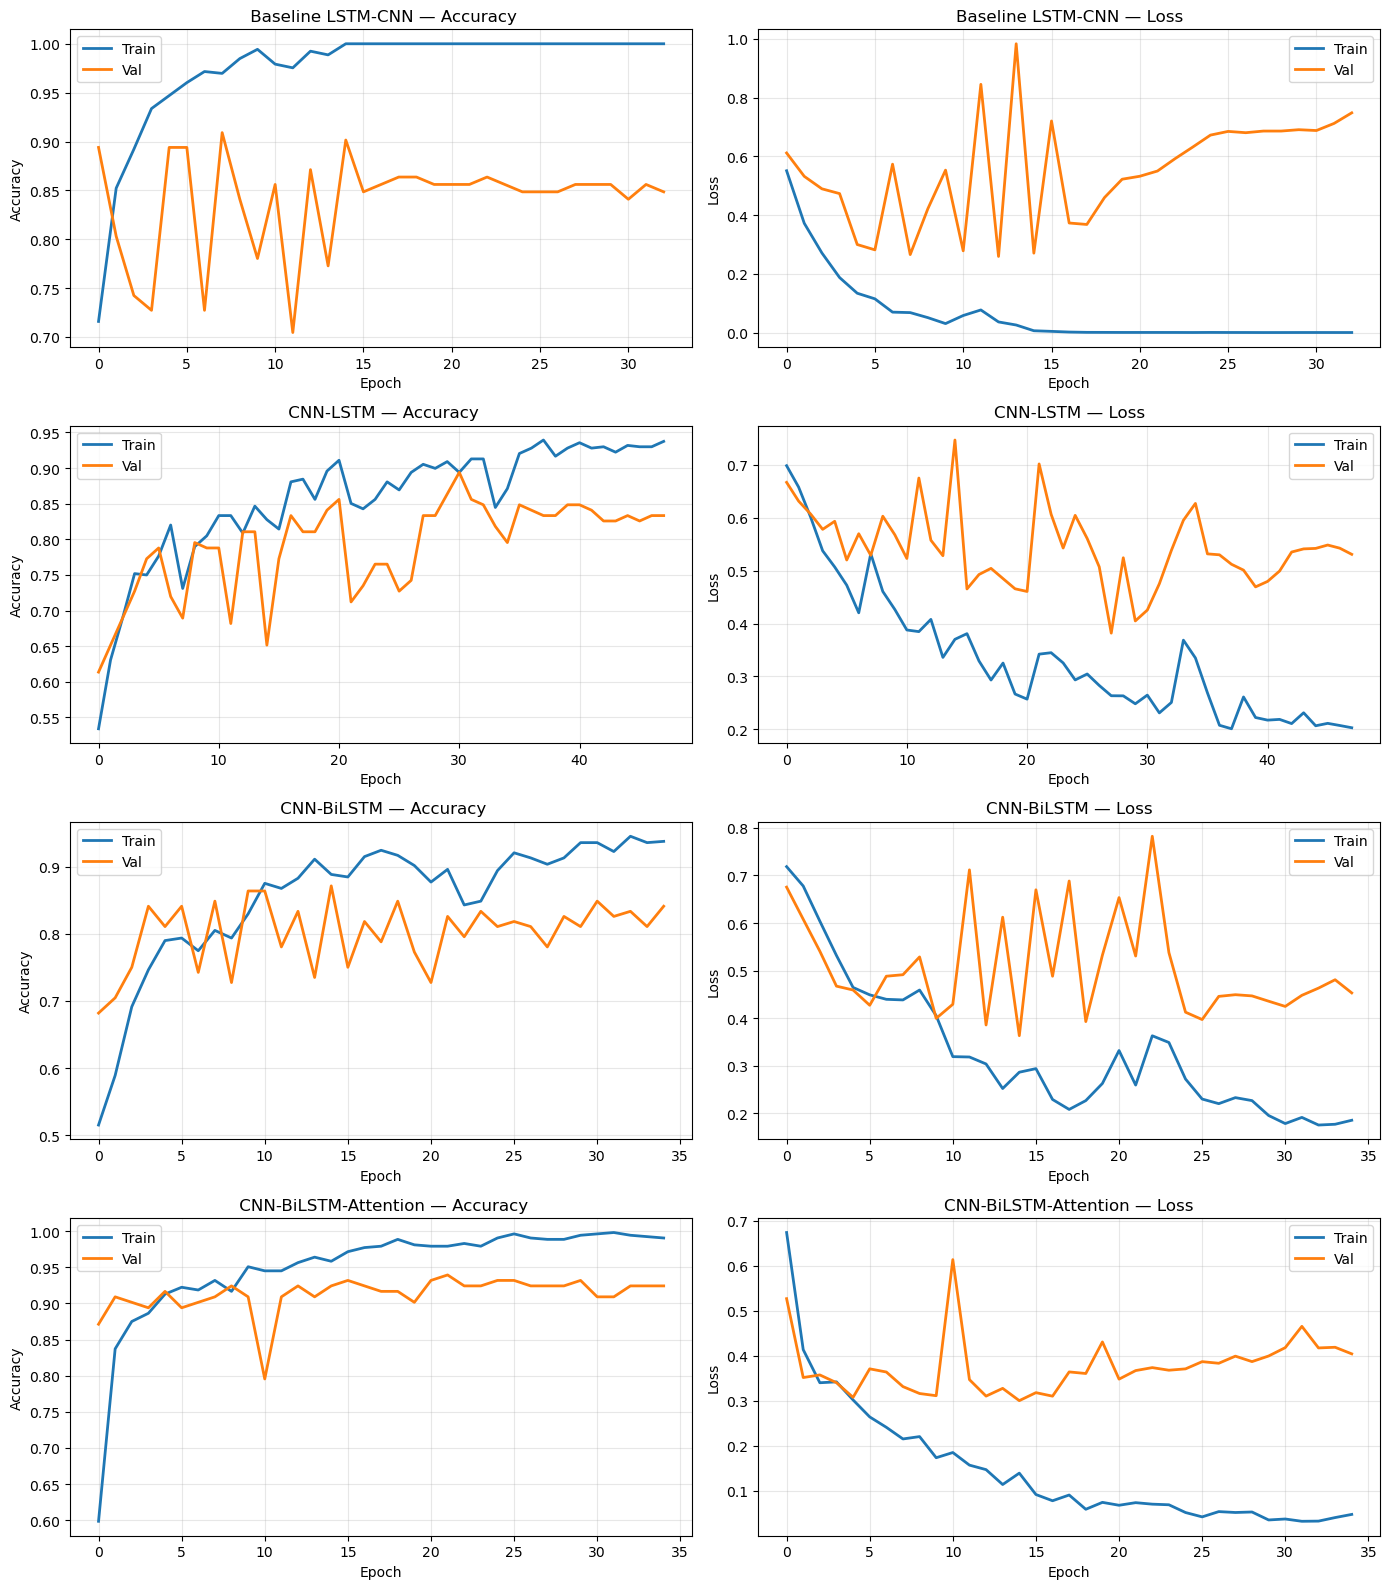

In [60]:
plot_training_history(histories)

## Evaluation -

In [61]:
def evaluate_model(model, X_te, y_te, name = "Model"):
    """
    Comprehensive evaluation with all requested metrics.
    Args:
        model: trained Keras model
        X_te: test features (normalized)
        y_te: test labels (integer, not one-hot)
        name: display name

    Returns:
        dict with all metrics + predictions
    """
    y_prob = model.predict(X_te, verbose = 0)
    y_pred = np.argmax(y_prob, axis = 1)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_te, y_pred)
    bal_acc = balanced_accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)

    # Sensitivity-
    sens = recall_score(y_te, y_pred)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_te, y_pred)

    try:
        auc = roc_auc_score(y_te, y_prob[:, 1])
    except Exception:
        auc = 0.0

    print(f"\n{'=' * 50}")
    print(f"{name}")
    print(f"{'=' * 50}")
    print(f" Accuracy : {acc:.4f}")
    print(f" Balanced Accuracy : {bal_acc:.4f}")
    print(f" Precision : {prec:.4f}")
    print(f" Sensitivity/Recall : {sens:.4f}")
    print(f" Specificity : {spec:.4f}")
    print(f" F1-score : {f1:.4f}")
    print(f" ROC-AUC : {auc:.4f}")
    print( )


    print(classification_report(
        y_te, y_pred,
        target_names=['Eyes-Open', 'Eyes-Closed']
    ))

    return {
        'name': name, 
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'precision': prec, 
        'sensitivity': sens,
        'specificity': spec, 
        'f1': f1, 
        'auc': auc,
        'cm': cm, 
        'y_pred': y_pred, 
        'y_prob': y_prob
    }


print("Evaluation function ready.")

Evaluation function ready.


### Evaluate on Validation Set

In [62]:
# EVALUATE ALL MODELS ON VALIDATION SET -

val_results = {}
for name, model in trained_models.items():
    val_results[name] = evaluate_model(
        model, X_val, y_val, f"{name} (Val)"
    )

# Select best model by validation balanced accuracy -
best_name = max(
    val_results,
    key=lambda k: val_results[k]['balanced_accuracy']
)
print(f"\n Best model by val balanced accuracy: {best_name}")


Baseline LSTM-CNN (Val)
 Accuracy : 0.8712
 Balanced Accuracy : 0.8712
 Precision : 0.9455
 Sensitivity/Recall : 0.7879
 Specificity : 0.9545
 F1-score : 0.8595
 ROC-AUC : 0.9738

              precision    recall  f1-score   support

   Eyes-Open       0.82      0.95      0.88        66
 Eyes-Closed       0.95      0.79      0.86        66

    accuracy                           0.87       132
   macro avg       0.88      0.87      0.87       132
weighted avg       0.88      0.87      0.87       132


CNN-LSTM (Val)
 Accuracy : 0.8333
 Balanced Accuracy : 0.8333
 Precision : 0.8793
 Sensitivity/Recall : 0.7727
 Specificity : 0.8939
 F1-score : 0.8226
 ROC-AUC : 0.9311

              precision    recall  f1-score   support

   Eyes-Open       0.80      0.89      0.84        66
 Eyes-Closed       0.88      0.77      0.82        66

    accuracy                           0.83       132
   macro avg       0.84      0.83      0.83       132
weighted avg       0.84      0.83      0.83     

### Evaluate Best Model on Test Set (single final evaluation)

> **Important:** This is the only time the test set is used.
> Model was selected based on validation performance.

In [63]:
# FINAL TEST EVALUATION (best model only)

print(f" Selected model: {best_name}")
print(f" Evaluating on {len(X_test)} test segments "
      f"({len(test_subj)} subjects)")

final_test_result = evaluate_model(
    trained_models[best_name],
    X_test,
    y_test,
    f"{best_name} (FINAL TEST)"
)

# Also evaluate all models on test for comparison table -
all_test_results = {}
for name, model in trained_models.items():
    all_test_results[name] = evaluate_model(
        model, X_test, y_test, f"{name} (Test)"
    )

 Selected model: CNN-BiLSTM-Attention
 Evaluating on 220 test segments (10 subjects)

CNN-BiLSTM-Attention (FINAL TEST)
 Accuracy : 0.8591
 Balanced Accuracy : 0.8591
 Precision : 0.8319
 Sensitivity/Recall : 0.9000
 Specificity : 0.8182
 F1-score : 0.8646
 ROC-AUC : 0.9518

              precision    recall  f1-score   support

   Eyes-Open       0.89      0.82      0.85       110
 Eyes-Closed       0.83      0.90      0.86       110

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220


Baseline LSTM-CNN (Test)
 Accuracy : 0.8318
 Balanced Accuracy : 0.8318
 Precision : 0.8614
 Sensitivity/Recall : 0.7909
 Specificity : 0.8727
 F1-score : 0.8246
 ROC-AUC : 0.9231

              precision    recall  f1-score   support

   Eyes-Open       0.81      0.87      0.84       110
 Eyes-Closed       0.86      0.79      0.82       110

    accuracy                           0.83       2

## Confusion Matrices

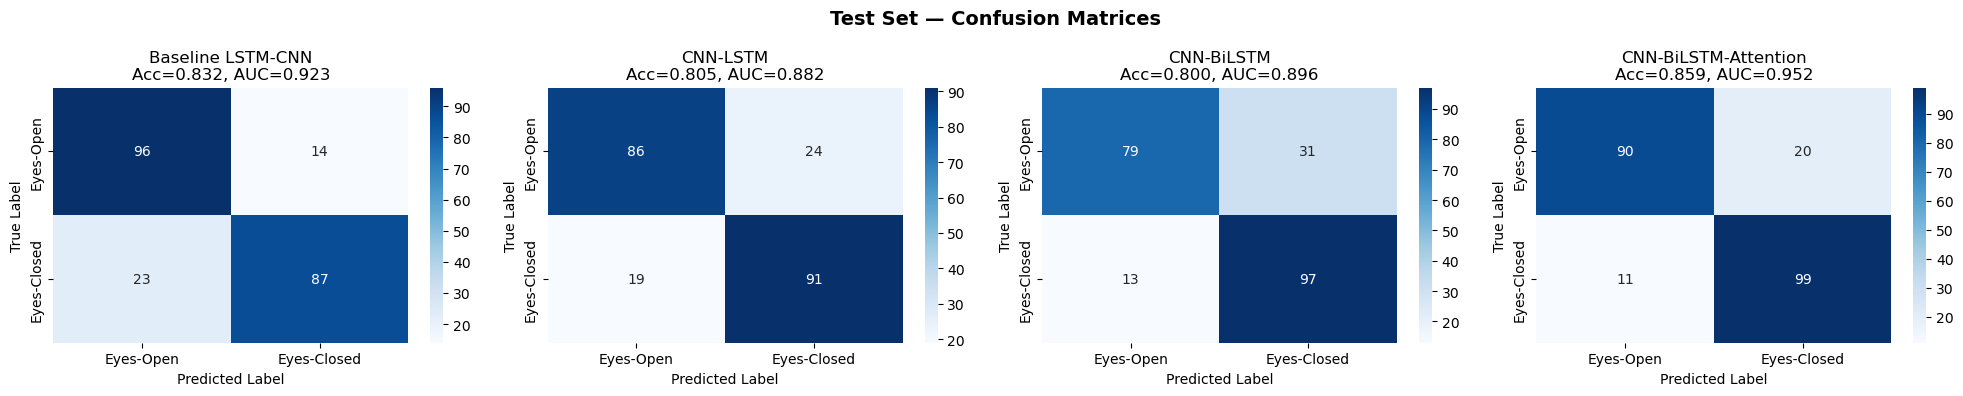

In [64]:
def plot_confusion_matrices( results_dict, title = "Confusion Matrices"):

    results = list(results_dict.values())
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, res in zip(axes, results):
        sns.heatmap(
            res['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Eyes-Open', 'Eyes-Closed'],
            yticklabels=['Eyes-Open', 'Eyes-Closed'],
            ax=ax
        )
        ax.set_title(
            f"{res['name'].split(' (')[0]}\n"
            f"Acc={res['accuracy']:.3f}, AUC={res['auc']:.3f}"
        )
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Plot test confusion matrices
plot_confusion_matrices(all_test_results, "Test Set \u2014 Confusion Matrices")

## ROC Curves -

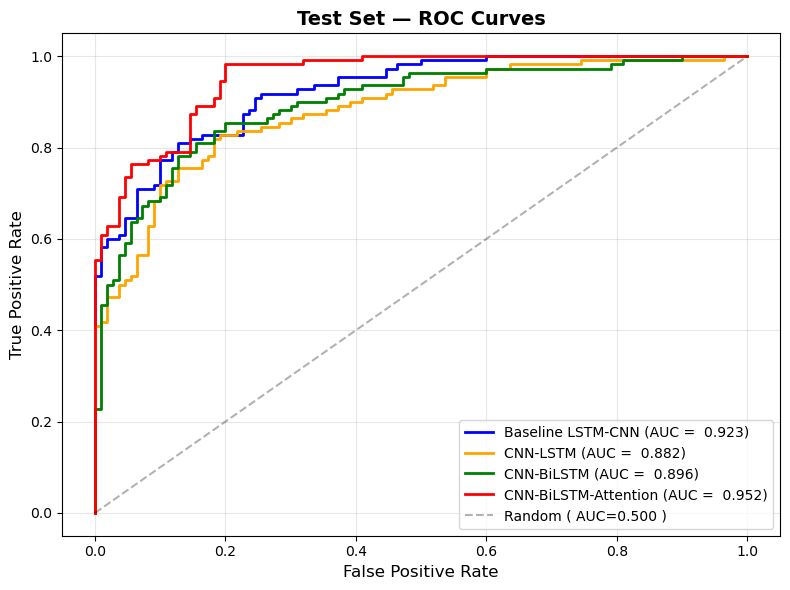

In [65]:
def plot_roc_curves(results_dict, y_true, title = "ROC Curves"):

    plt.figure(figsize=(8, 6))

    colors = [
    'blue',
    'orange',
    'green',
    'red',
    'purple'
]

    for i, (name, res) in enumerate(results_dict.items()):

        fpr, tpr, _ = roc_curve(y_true, res['y_prob'][:, 1])
        color = colors[i % len(colors)]

        plt.plot(
            fpr, tpr,
            linewidth = 2 , color = color,
            label = f"{name} (AUC = {res['auc']: .3f})"
        )

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label = 'Random ( AUC=0.500 )')
    plt.xlabel('False Positive Rate', fontsize = 12)
    plt.ylabel('True Positive Rate', fontsize = 12)
    plt.title(title, fontsize = 14, fontweight = 'bold')
    plt.legend(loc = 'lower right', fontsize = 10)
    plt.grid(alpha = 0.3)
    plt.tight_layout()
    plt.show()


# Plot test ROC curves -
plot_roc_curves(all_test_results, y_test, "Test Set \u2014 ROC Curves")

## Subject-wise Cross-Validation

**GroupKFold** ensures complete subject separation in every fold.
Per-fold normalization prevents any information leakage.

> This uses ALL data (not the train/val/test split) for unbiased estimation.

In [66]:
def cross_validate_model(
    build_fn, X, y, groups,
    name="Model",
    n_folds=N_FOLDS
):

    gkf = GroupKFold (n_splits = n_folds)

    metric_names = [
        'accuracy', 'balanced_accuracy', 'precision',
        'sensitivity', 'specificity', 'f1', 'auc'
    ]
    fold_metrics = {m: [] for m in metric_names}

    for fold, (tr_idx, val_idx) in enumerate(
        gkf.split(X, y, groups=groups), 1
    ):
        print(f"\n {name} | Fold {fold}/{n_folds} ")

        X_tr, X_vl = X[tr_idx], X[val_idx]
        y_tr, y_vl = y[tr_idx], y[val_idx]

        tr_subj = np.unique (groups[tr_idx])
        vl_subj = np.unique (groups[val_idx])
        print(f" Train: {len(X_tr)} seg, {len(tr_subj)} subj | "
              f"Val: {len(X_vl)} seg, {len(vl_subj)} subj")

        # Per-fold normalization -
        mu_f = X_tr.mean(axis=(0, 1), keepdims=True)
        sigma_f = X_tr.std(axis=(0, 1), keepdims=True) + 1e-8
        X_tr = (X_tr - mu_f) / sigma_f
        X_vl = (X_vl - mu_f) / sigma_f

        # Class weights -
        cls = np.unique(y_tr)
        wts = compute_class_weight('balanced', classes=cls, y=y_tr)
        cw = dict(zip(cls.astype(int), wts))

        # Build fresh model -
        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_SEED + fold)
        model = build_fn(
            input_shape=(X_tr.shape[1], X_tr.shape[2]),
            n_classes=N_CLASSES
        )

        # Categorical labels -
        y_tr_cat = to_categorical(y_tr, N_CLASSES)
        y_vl_cat = to_categorical(y_vl, N_CLASSES)

        # Callbacks -
        callbacks = [
            EarlyStopping(
                monitor='val_loss', patience=15,
                restore_best_weights=True, verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=6, verbose=0
            ),
        ]

        # Train -
        model.fit(
            X_tr, y_tr_cat,
            validation_data=(X_vl, y_vl_cat),
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            callbacks=callbacks,
            class_weight=cw,
            verbose=0
        )

        # Evaluate -
        result = evaluate_model(model, X_vl, y_vl, f"{name} Fold {fold}")

        for m in metric_names:
            fold_metrics[m].append(result[m])

        del model

    # Summary -
    print(f"\n {'=' * 60}")
    print(f"{name} \u2014 {n_folds}-Fold CV Summary")
    print(f"{'=' * 60}")

    summary = {}
    for m in metric_names:
        vals = fold_metrics[m]
        mean_v = np.mean(vals)
        std_v = np.std(vals)
        summary[m] = (mean_v, std_v)
        print(f"  {m:<22s}: {mean_v:.4f} +/- {std_v:.4f}")

    return {'name': name, 'fold_metrics': fold_metrics, 'summary': summary}


print("Cross-validation function ready.")

Cross-validation function ready.


### Run Cross-Validation -

In [67]:
# RUN CROSS-VALIDATION FOR ALL MODELS

cv_results = {}

if RUN_CV:
    print(f"Running {N_FOLDS}-fold subject-grouped cross-validation.")

    print(f"Total: {len(X_all)} segments, "
          f"{len(np.unique(subject_ids_all))} subjects\n")

    for name, build_fn in model_builders.items():
        cv_results[name] = cross_validate_model(
            build_fn,
            X_all,
            y_all,
            subject_ids_all,
            name=name,
            n_folds=N_FOLDS
        )

    print("\nCross-validation complete!")
else:
    print("Cross-validation skipped.")
    print("Set RUN_CV = True and re-run this cell to enable.")

Running 3-fold subject-grouped cross-validation.
Total: 880 segments, 40 subjects


 Baseline LSTM-CNN | Fold 1/3 
 Train: 572 seg, 26 subj | Val: 308 seg, 14 subj

Baseline LSTM-CNN Fold 1
 Accuracy : 0.8084
 Balanced Accuracy : 0.8084
 Precision : 0.7487
 Sensitivity/Recall : 0.9286
 Specificity : 0.6883
 F1-score : 0.8290
 ROC-AUC : 0.9102

              precision    recall  f1-score   support

   Eyes-Open       0.91      0.69      0.78       154
 Eyes-Closed       0.75      0.93      0.83       154

    accuracy                           0.81       308
   macro avg       0.83      0.81      0.81       308
weighted avg       0.83      0.81      0.81       308


 Baseline LSTM-CNN | Fold 2/3 
 Train: 594 seg, 27 subj | Val: 286 seg, 13 subj

Baseline LSTM-CNN Fold 2
 Accuracy : 0.8357
 Balanced Accuracy : 0.8357
 Precision : 0.7892
 Sensitivity/Recall : 0.9161
 Specificity : 0.7552
 F1-score : 0.8479
 ROC-AUC : 0.9267

              precision    recall  f1-score   support

   Eyes-O

## Model Comparison Table

In [68]:
# COMPARISON TABLE

metrics_display = [
    ('accuracy', 'Accuracy'),
    ('balanced_accuracy', 'Bal.Acc'),
    ('precision', 'Precision'),
    ('sensitivity', 'Recall'),
    ('specificity', 'Spec.'),
    ('f1', 'F1'),
    ('auc', 'AUC'),
]

# Validation Results -
print("=" * 100)
print("VALIDATION SET RESULTS (used for model selection)")
print("=" * 100)

header = f"{'Model':<25s}"
for _, label in metrics_display:
    header += f" {label:>10s}"
print(header)
print("-" * len(header))

for name in model_builders:
    if name in val_results:
        res = val_results[name]
        row = f"{name:<25s}"
        for key, _ in metrics_display:
            row += f" {res[key]:>10.4f}"
        print(row)


VALIDATION SET RESULTS (used for model selection)
Model                       Accuracy    Bal.Acc  Precision     Recall      Spec.         F1        AUC
------------------------------------------------------------------------------------------------------
Baseline LSTM-CNN             0.8712     0.8712     0.9455     0.7879     0.9545     0.8595     0.9738
CNN-LSTM                      0.8333     0.8333     0.8793     0.7727     0.8939     0.8226     0.9311
CNN-BiLSTM                    0.8712     0.8712     0.8451     0.9091     0.8333     0.8759     0.9295
CNN-BiLSTM-Attention          0.9242     0.9242     0.9242     0.9242     0.9242     0.9242     0.9490


In [69]:

# Test Results -

print(f"\n {'=' * 100}")
print("TEST SET RESULTS. ")
print("=" * 100)

header = f"{'Model':< 25s}"
for _, label in metrics_display:
    header += f" {label:> 10s}"

print(header)
print("-" * len(header))

for name in model_builders:

    if name in all_test_results:

        res = all_test_results[name]
        marker = " ***" if name == best_name else ""
        row = f"{name:<25s}"

        for key, _ in metrics_display:
            row += f" {res[key]:>10.4f}"
        print(row + marker)

print(f"\n = Best model which selected on validation set")


TEST SET RESULTS. 


ValueError: Space not allowed in string format specifier

In [ ]:
# Cross-Validation Results -

if cv_results:

    print(f"\n{'=' * 100}")
    print(f"{N_FOLDS}-FOLD CROSS-VALIDATION RESULTS ")
    print("=" * 100)


    header = f"{'Model':<25s}"
    for _, label in metrics_display:
        header += f" {label:>14s}"

    print(header)
    print("-" * len(header))


    for name in model_builders:

        if name in cv_results:

            s = cv_results[name]['summary']
            row = f"{name:<25s}"

            for key, _ in metrics_display:
                mean, std = s[key]
                row += f" {mean:.3f}+/-{std:.3f}"
                
            print(row)

## Final Results & Summary

In [ ]:
# FINAL SUMMARY

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n Dataset: EEGMMIDB ({ len(np.unique(subject_ids_all))} subjects)")
print(f" Task: Eyes-Open vs Eyes-Closed classification")
print(f" Preprocessing: Bandpass 1-45 Hz, Notch 60 Hz")
print(f"Segment: {SEGMENT_SEC}s ({N_SAMPLES} samples x {N_CHANNELS} channels)")
print(f"Split: {len(train_subj)} train / {len(val_subj)} val / {len(test_subj)} test subjects")

print(f"\nBest model: {best_name}")
print(f"Selected by: validation balanced accuracy")

r = final_test_result
print(f"\n--- Test Set Performance ---")
print(f" Accuracy : {r['accuracy']:.4f}")
print(f" Balanced Accuracy : {r['balanced_accuracy']:.4f}")
print(f" Precision : {r['precision']:.4f}")
print(f" Sensitivity/Recall : {r['sensitivity']:.4f}")
print(f" Specificity : {r['specificity']:.4f}")
print(f" F1-score : {r['f1']:.4f}")
print(f" ROC-AUC : {r['auc']:.4f}")

if cv_results and best_name in cv_results:

    s = cv_results[best_name]['summary']

    print(f"\n--- Cross-Validation Performance ---")
    for m in ['accuracy', 'balanced_accuracy', 'f1', 'auc']:
        mean, std = s[m]
        
        print(f"  {m:<22s}: {mean:.4f} +/- {std:.4f}")
